<a href="https://colab.research.google.com/github/cedizen/detection_automatique_faux_billets/blob/main/berthezene_projet12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projet: Lutte contre la contrefaçon des billets de banque**

Ce notebook s'inscrit dans un projet de lutte contre la contrefaçon des billets de banque à l'aide de techniques de machine learning.
Il repose sur un jeu de données contenant 1 500 billets, décrits par leurs caractéristiques physiques et leur nature réelle (vrai ou faux).

L'objectif de ce notebook est de préparer les données et d'entraîner plusieurs modèles de classification afin d'évaluer leur capacité à identifier les faux billets.

Les étapes abordées incluent l'exploration des données, la préparation des variables et l'évaluation des performances des modèles.
Les résultats obtenus serviront de base pour le choix du modèle le plus pertinent.

This notebook is part of a project focused on detecting counterfeit banknotes using machine learning techniques.

It is based on a dataset of 1500 banknotes, described by their physical characteristics and their true nature (genuine or counterfeit).

The purpose of this notebook is to prepare data and train several classification models in order to evaluate their ability to indentify counterfeit banknotes.

The analysis include data exploration, preprocessing and models performance evaluation. The results obtained will support the selection of the best accurate model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
root_project = '/content/drive/MyDrive/projet_faux_monnayage/'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Import train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import numpy as np
from scipy.stats import mode

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans


from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score
# Function to display the resultst inside the confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
billets_df = pd.read_csv(f"{root_project}data/billets.csv")

# **Functions**

## **Preprocessing data**

This section defines the complete process, from data splitting to workflow construction, including standardization and model application.

This step is typically performed before model training in order to clearly separate preprocessing from the model itself, thereby preventing data leakage.

Once properly specified, the pipeline, creates a single, independent workflow that can be consistently applied accross all models.

In [6]:
# state the data to know
# Args, dataframe and a target
# return a train dataframe and a target feature
def state_data(df, targ):
  X = df.drop(targ, axis=1)
  y = df[targ]
  return X, y

# Tra
def train_split_data(X, y, size, stratify=None):
  X_train_genuine, X_test_genuine, y_train_genuine, y_test_genuine = train_test_split(
      X, y, test_size=size, stratify=stratify, random_state=42
  )
  return X_train_genuine, X_test_genuine, y_train_genuine, y_test_genuine

# build a pipeline to unify a logical and ordered process within a workflow
# make it independent from the rest to avoid data leakage and only associated to the model
def make_pipeline(model, scale=False):
  # instantiate a list
  steps = []
  # need to order it
  if scale == True:
    # first: we scale the data if the model require
    steps.append(("scaler", StandardScaler()))
  # second: we attach the modle
  steps.append(("model", model()))
  return Pipeline(steps)

### **Unsupervised models evaluation**

This section describe how unsupervised models are handled, as they differ fundamentally from supervised ones. In this context, no target variable is provided, and the data are grouped based solely on shared characteristics.

Consequently, the use of a confusion matrix is innapropriate, since clusters are not true predictions but numerical identifiers assigned to group similar observations.

To evaluate both training and test datasets, internal clustering metrics such as silhouette score (usually the most basic one and the easiest to interpretate) will be used. This metric measures how well each data data point fits within its assigned cluster compared to other clusters, providing an indicatr of cluster cohesion and separation.

In [7]:
# function which takes a file, a list of models and for each one evaluate it through
# a confusion_matrix and return an object with the name of the best score linked with the model
def evaluate_best_unsupervised_model_training(X_train,
                    X_test,
                                 unsupervised_pipelines, params_clustering):

    # we evaluate the best model on the train dataset with GridSearchCV
  unsupervised_train_results = []

    # we loop through the models
  for name, pipeline in unsupervised_pipelines.items():

      pipeline.set_params(**params_clustering[name])
      pipeline.fit(X_train)
      y_pred = pipeline.predict(X_test)
      best_score = silhouette_score(X_test, y_pred)
      best_params = None # KMeans doesn't have best_params in the same way

      unsupervised_train_results.append({'best_model_name': pipeline.named_steps["model"].__class__.__name__,
                          'best_model': pipeline,
                          'best_score': best_score,
                          'best_params':best_params
                          })

  # We store the results in the list of evaluating models
  best_results_unsupervised_train = max(unsupervised_train_results, key=lambda x: x['best_score'])

  return best_results_unsupervised_train

def evaluate_best_unsupervised_model_confusion_matrix(X_train, X_test, best_unsupervised_training_model=None):

  if best_unsupervised_training_model is not None:
    best_trained_model_name = best_unsupervised_training_model["best_model_name"]
    best_trained_model_instance = best_unsupervised_training_model["best_model"]
    best_trained_score = best_unsupervised_training_model["best_score"]
    best_trained_params = best_unsupervised_training_model["best_params"]

  test_results = []

      # we loop through the model
  best_trained_model_instance.fit(X_train)
  label = best_trained_model_instance.predict(X_test)
  score = silhouette_score(X_test, label)

  test_results.append({'best_model_name': best_trained_model_name,
                          'best_model': best_trained_model_instance,
                          'best_test_score': score,
                       "best_trained_score": best_trained_score })
  best_results_test = max(test_results, key=lambda x: x['best_trained_score'])

  return best_results_test

### **Supervised model evaluations**

As described in the previous section, which explains, how unsupervised models are handled, this sections focuses on supervised models and how their predictions processess are constructed.

In supervised learning, a target variable is always required and is separated from the remaining features, which are then used to train a predictive model.

Model performance is commonly evaluated using a confusion matrix, which summarizes the number of true positives, true negatives, false positives, and false negatives in a four-cell table providing insight into the model's classification behavior.

In [8]:
def display_results_cm(cm):
  # Create a figure
  TN = cm[0][0]
  FP = cm[0][1]
  FN = cm[1][0]
  TP = cm[1][1]
  TP_rate = TP/(TP+FN)
  TN_rate = TN/(TN+FP)
  FP_rate = FP/(FP+TN)
  FN_rate = FN/(FN+TP)
  accuracy_score = (TP+TN)/(TP+TN+FP+FN)
  f1_score = TP/(TP+0.5*(FP+FN))

  return FP, FN, f1_score


def evaluate_best_model_supervised_training(
    X_train, X_test, y_train, y_test, pipelines, params_classification, scoring="f1"):

  supervised_train_results = []

  for name, pipeline in pipelines.items():
      grid_search = GridSearchCV(pipeline, param_grid=params_classification[name], cv=5, scoring=scoring, n_jobs=-1)
      grid_search.fit(X_train, y_train)
      best_model = grid_search.best_estimator_
      best_score = grid_search.best_score_
      best_params = grid_search.best_params_

      supervised_train_results.append({
      'best_model_name': pipeline.named_steps["model"].__class__.__name__,
      'best_model': pipeline,
      'best_score': best_score,
      'best_params':best_params })
        # We store the results in the list of evaluating models
  best_supervised_results_train = max(supervised_train_results, key=lambda x: x['best_score'])

  return best_supervised_results_train

#


# this function rr
def evaluate_best_supervised_model_confusion_matrix(X_train, X_test, y_train, y_test, best_supervised_training_model=None):

  if best_supervised_training_model is not None:
    best_trained_model_name = best_supervised_training_model["best_model_name"]
    best_trained_model_instance = best_supervised_training_model["best_model"]
    best_trained_score = best_supervised_training_model["best_score"]
    best_trained_params = best_supervised_training_model["best_params"]

  test_results = []

  # Now we will evaluate each model model also with confusion matrix
  best_trained_model_instance.fit(X_train, y_train)
  y_pred = best_trained_model_instance.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  FN, FP, score = display_results_cm(cm)
  cr = classification_report(y_test, y_pred)

  test_results.append({'best_model_name': best_trained_model_name,
                          'best_model': best_trained_model_instance,
                          'best_test_score': score,
                       "FP": FP,
                       "FN": FN,
                       "best_trained_score": best_trained_score,
                       "best_trained_params": best_trained_params,
                          "classification_report": cr })

  best_results_test = max(test_results, key=lambda x: x['best_trained_score'])

  return best_results_test


### **Main function**

All the other fuction can be used independently to specific processing steps when needed or included into a final wrapper function that accepts all relevant parameters, making the overall workflow easier and more convenient to use.

In [9]:
def detect_true_false_money(df, colum_target,
                            supervised_pipelines=None,
                            unsupervised_pipelines=None,
                            params_classification=None, params_clustering=None):
  # initiliaze the data
  X_low, y_low = state_data(df, colum_target)

  # split the data into trained model and test set
  X_train_low, X_test_low, y_train_low, y_test_low = train_split_data(X_low, y_low, size=0.2, stratify=y_low)

  if supervised_pipelines is not None:

    # Function for the supervised training and test part
    best_supervised_training_model = \
    evaluate_best_model_supervised_training(X_train_low,
                                X_test_low,
                                y_train_low,
                                y_test_low,
                                supervised_pipelines, params_classification)

    best_supervised_results_test = evaluate_best_supervised_model_confusion_matrix(
    X_train_low, X_test_low, y_train_low, y_test_low, best_supervised_training_model)

  if unsupervised_pipelines is not None:

    # Function for the supervised training and tests part
    best_unsupervised_training_model = \
    evaluate_best_unsupervised_model_training(X_train_low,
                                X_test_low,
                                unsupervised_pipelines, params_clustering)

    best_unsupervised_results_test = evaluate_best_unsupervised_model_confusion_matrix(
      X_train_low, X_test_low, best_unsupervised_training_model)

  return best_unsupervised_results_test, best_supervised_results_test

### **Others**

Other mischellaneous functions that can make some task easier to handle and avoid redundancy.

In [10]:
def calculate_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  return IQR


# Return the number of rows depeding on the number of cols and the cols given as parameters
# By default, ncols = 1, that mean one element per col

def n_rows(cols, ncols=1):
  n_elements=len(cols)
  return math.ceil(n_elements/ncols)

In [11]:
# import the CSV file
billets_df = pd.read_csv("/content/drive/MyDrive/projet_faux_monnayage/data/billets.csv", sep=";")

In [12]:
billets_df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [13]:
billets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


Some features seems to have missing values

In [14]:
billets_df.isna().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0


37 values seems to be missing. According to the company wishes, they want it to be filled with some predicted values. Let's decide which model we will select based on multiple criterias.

In [15]:
for col in billets_df.columns:
    display(billets_df[col].describe())

,is_genuine
count,1500
unique,2
top,True
freq,1000


,diagonal
count,1500.000000
mean,171.958440
std,0.305195
min,171.040000
25%,171.750000
50%,171.960000
75%,172.170000
max,173.010000


,height_left
count,1500.000000
mean,104.029533
std,0.299462
min,103.140000
25%,103.820000
50%,104.040000
75%,104.230000
max,104.880000


,height_right
count,1500.000000
mean,103.920307
std,0.325627
min,102.820000
25%,103.710000
50%,103.920000
75%,104.150000
max,104.950000


,margin_low
count,1463.000000
mean,4.485967
std,0.663813
min,2.980000
25%,4.015000
50%,4.310000
75%,4.870000
max,6.900000


,margin_up
count,1500.000000
mean,3.151473
std,0.231813
min,2.270000
25%,2.990000
50%,3.140000
75%,3.310000
max,3.910000


,length
count,1500.00000
mean,112.67850
std,0.87273
min,109.49000
25%,112.03000
50%,112.96000
75%,113.34000
max,114.44000


# **Buidling a model to find missing margin low values**

Based on previous observations, we noticed that one feature had missing values.
That part will focus on deciding which model will be used to handle and predict the missing outcome. To choose the accurate one, some criterias may be evaluated as:
- What kind of outcome is it (numerical or categorical) ?
- Are there any correlations ?
- How many missing values are observed compare to the dataset length ?

Does the missing feature has a strong correlation with the other ones ? Because it seems to be an important criterias to build a predicted model to fill the missing values.

In [16]:
billets_df["margin_low"].dtype

dtype('float64')

This feature is a float outcome that means numerical

## **Correlations between the target feature and others**

Are there any correlations between the target feature and the other ones ?

In [17]:
import seaborn as sns

In [18]:
target_low = "margin_low"

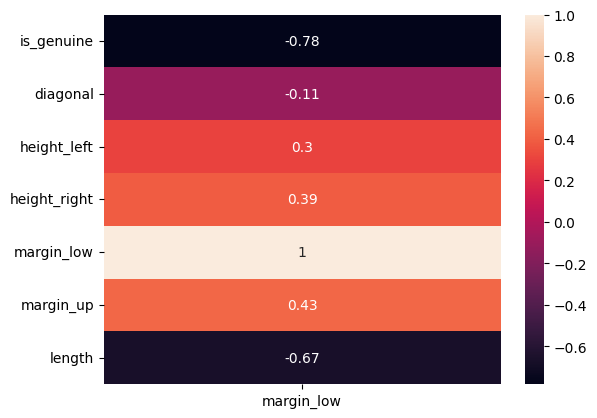

In [19]:
sns.heatmap(billets_df.corr()[[target_low]], annot=True)
plt.show()

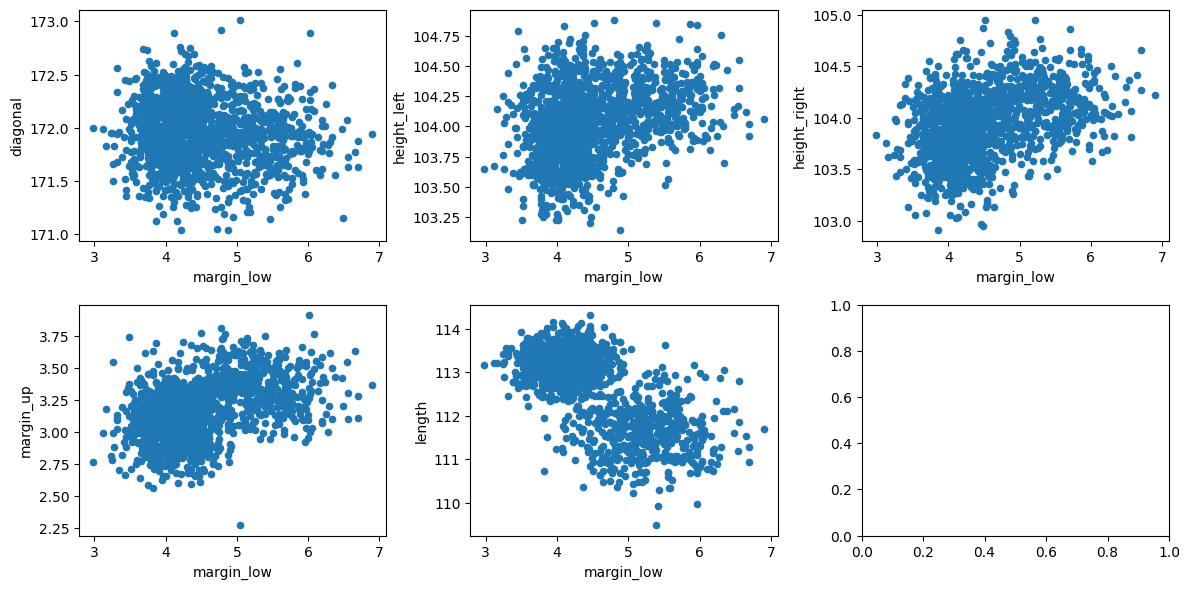

In [20]:
import math

columns_corr=billets_df.drop([target_low, "is_genuine"], axis=1).columns

ncols = 3
nrows = math.ceil(len(columns_corr) / ncols)
fig, axes= plt.subplots(nrows, ncols, figsize=(12,6))
# to flat the axes to avoid multindexes
axes = axes.flatten()

for i, col in enumerate(columns_corr):
  billets_df.plot(
      kind="scatter",
      x=target_low,
      y=col,
      ax=axes[i]
  )
plt.tight_layout()
plt.show()

All features compare to margin low are strongly correlated either positively or negatively. So a linear regression is completely feasible

## **Outliers detection ?**

Detecting outliers is important to be sure that results won't be distorted as some models used can be really sensitive. And even if the model is more robust, exclude too extreme data can is always a good pratice and good habits in any cases.

How are values distributed ? Are there outliers ?

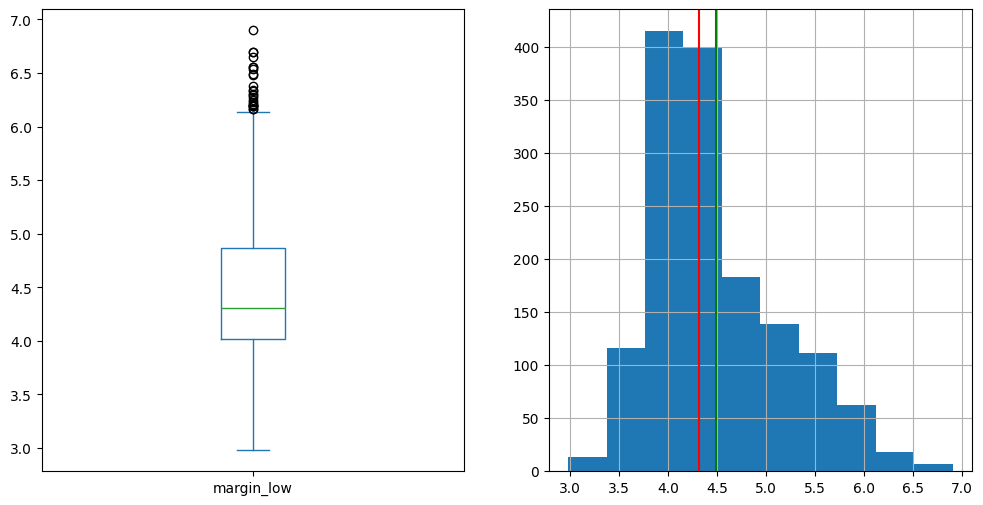

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Check how the margin low is distributed to avoid

billets_df[target_low].plot(kind="box", ax=axes[0])

billets_df[target_low].hist(ax=axes[1])
# display the median line
plt.axvline(billets_df[target_low].median(), color='red')
plt.axvline(billets_df[target_low].mean(), color='green')

plt.show()

In [22]:
billets_df[target_low].describe()

,margin_low
count,1463.000000
mean,4.485967
std,0.663813
min,2.980000
25%,4.015000
50%,4.310000
75%,4.870000
max,6.900000


How many data for extrem outliers ?

In [23]:
IQR = calculate_iqr(billets_df, target_low)

Method to detect extreme outliers that can affect the results

In [24]:
upper_whisker_extreme = billets_df[target_low].quantile(0.75) + 3 * IQR

In [25]:
extreme_outliers = billets_df[billets_df[target_low] > upper_whisker_extreme][target_low]

In [26]:
extreme_outliers_rate = extreme_outliers.count() / billets_df[target_low].count()
print(f"Extreme outliers accounts for \"{target_low}\": {extreme_outliers_rate*100:.2f}%")

Extreme outliers accounts for "margin_low": 0.00%


No extreme outliers. Hence, models won't be affected by extreme points that tend to stretch the line and distord the results.

And for normal outliers ?

In [27]:
upper_whisker_normal = billets_df[target_low].quantile(0.75) + 1.5 * IQR

In [28]:
outliers = billets_df[billets_df[target_low] > upper_whisker_normal][target_low]

In [29]:
outliers_rate = outliers.count() / len(billets_df)
print(f"Outliers for \"{target_low}\": {outliers.count()} over {billets_df[target_low].count()}")
print(f"Outliers rate for \"{target_low}\": {outliers_rate*100:.2f}%")

Outliers for "margin_low": 24 over 1463
Outliers rate for "margin_low": 1.60%


Not a significant amount of outliers (<3%) that reduce their impact on the results and on prediction models performance. And can we infer that there are outliers

Not too much skewed with some outliers observed but relatively equally distributed between values, with median and mean ranged within the highest amount of observed data.

How many values are missing ?

In [30]:
missing_values = billets_df.isna().sum()

In [31]:
missing_rate = missing_values[missing_values > 0] / billets_df.shape[0]
print(f"Missing values rate: {missing_rate.iloc[0] *100:.2f}%")

Missing values rate: 2.47%


2,47% of missing values, that means a low number of values missing to avoid having not enough filled values to have valid results.

Based on all data observed previously, the target outcome is numerical. No real outliers are observed

In [32]:
# Filter the row where the margin_low is null
train_data = billets_df[billets_df["margin_low"].notnull()]

# Filter the row where the margin_low is not null
missing_data = billets_df[billets_df["margin_low"].isnull()]
print(missing_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, 72 to 1438
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    37 non-null     bool   
 1   diagonal      37 non-null     float64
 2   height_left   37 non-null     float64
 3   height_right  37 non-null     float64
 4   margin_low    0 non-null      float64
 5   margin_up     37 non-null     float64
 6   length        37 non-null     float64
dtypes: bool(1), float64(6)
memory usage: 2.1 KB
None


## **Model prediction building**

In [33]:
# turn the categorical column into a binary column

X_train_dummies, y = state_data(pd.get_dummies(train_data, columns=['is_genuine'], drop_first=True),
                                      target_low)

# turn the missing values in numerical to get the same shape when predicting missing values
X_missing_dummies = pd.get_dummies(missing_data, columns=['is_genuine'], drop_first=True).drop(target_low, axis=1)

In [34]:
# Train the model
X_train_low, X_test_low, y_train_low, y_test_low = train_split_data(X_train_dummies, y, 0.3)

In [35]:
def evaluate_score_regression_model(model, X_train, X_test, y_train, y_test):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  score = r2_score(y_test, y_pred)
  return score

In [36]:
# from sklearn.linear_model import LinearRegression
linearReg = make_pipeline(LinearRegression, scale=True)

score_linreg_low = evaluate_score_regression_model(linearReg,
                                                   X_train_low,
                                                   X_test_low,
                                                   y_train_low,
                                                   y_test_low)
print(score_linreg_low)

0.6405334834302354


Let's try with another model to see if accuracy is better

In [37]:
from sklearn.linear_model import RidgeCV

# Try to confirm with another linear model ridge
paramRidge = {"model__alphas": [0.01, 0.1, 1, 10, 100]}
ridge = make_pipeline(RidgeCV, scale=True)
ridge.set_params(**paramRidge)

score_ridge_low = evaluate_score_regression_model(ridge,
                                                   X_train_low,
                                                   X_test_low,
                                                   y_train_low,
                                                   y_test_low)

print(score_ridge_low)

0.6404572588685216


Ridge and linear regression are the same

We can use also less fitted models such as DecisionTreeRegressor and RandomForestRegressor to see if the model predicts more accurately the values.

In [38]:
# Try another model
params_tr = {"model__max_depth":1, "model__random_state":42}
tr = make_pipeline(DecisionTreeRegressor, scale=True)
tr.set_params(**params_tr)
score_tr_low = evaluate_score_regression_model(tr,
                                                   X_train_low,
                                                   X_test_low,
                                                   y_train_low,
                                                   y_test_low)

print(score_tr_low)

0.6366992764369452


In [39]:
# Try another model
params_rf = {"model__n_estimators": 200,
    "model__max_depth": None,
    "model__random_state": 42,
    "model__n_jobs": -1}
rf = make_pipeline(RandomForestRegressor, scale=True)
rf.set_params(**params_rf)
score_rf_low = evaluate_score_regression_model(rf,
                                                   X_train_low,
                                                   X_test_low,
                                                   y_train_low,
                                                   y_test_low)

print(score_rf_low)

0.5936653490881957


New Section

In [40]:
models_low_columns = [LinearRegression.__name__,
                      RidgeCV.__name__,
                      DecisionTreeRegressor.__name__,
                      RandomForestRegressor.__name__]
scores_models_low = [score_linreg_low, score_ridge_low, score_tr_low, score_rf_low]

scores_models_low_df = pd.DataFrame(list(zip(models_low_columns, np.round(scores_models_low, 5))),
                                    columns=["Model", "Score"])
scores_models_low_df.sort_values("Score", ascending=False)

,Model,Score
0,LinearRegression,0.64053
1,RidgeCV,0.64046
2,DecisionTreeRegressor,0.63670
3,RandomForestRegressor,0.59367


In [41]:
best_model_low = scores_models_low_df[scores_models_low_df["Score"] == scores_models_low_df["Score"].max()]["Model"].iloc[0]
print(f"The best fitted model is {best_model_low}")

The best fitted model is LinearRegression


**LinearRegression** is the best fitted model compare to **RidgeCV**, **DecisionTreeRegressor** and **RandomForestRegressor**

In [42]:
predicted_values = linearReg.predict(X_missing_dummies)

In [43]:
# We fill the missing predicted margins low with the values predicted
billets_df.loc[billets_df[target_low].isnull(), target_low] = predicted_values

In [44]:
billets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [45]:
billets_df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# **Performance predictive model building**

**Objective:** build an algorithm to perform the most accurate prediction based on bills data.
The algorithm will first evaluate which model will perform the best on the training dataset and apply the same logic on the test dataset through a confusion matrix to assess how much positive and negative cases have been found.

let's see how data are distributed and if it exists for all of them a correlation either positive or negative

## **Data evaluation**

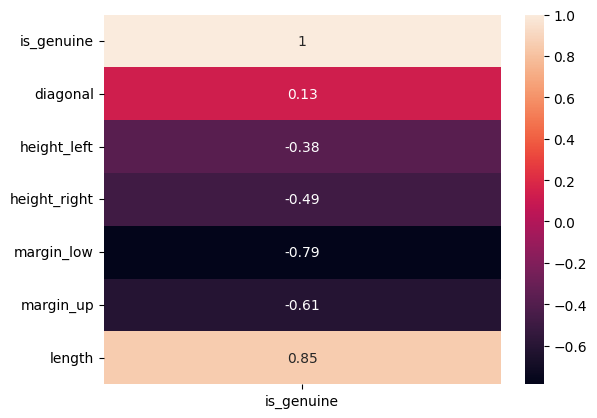

In [46]:
sns.heatmap(data=billets_df.corr()[["is_genuine"]], annot=True)
plt.show()

Let's check if there are some outliers that could falsify the results

In [47]:
cols_billets = billets_df.drop("is_genuine", axis=1).columns
ncols=3
nrows = n_rows(cols_billets, ncols)

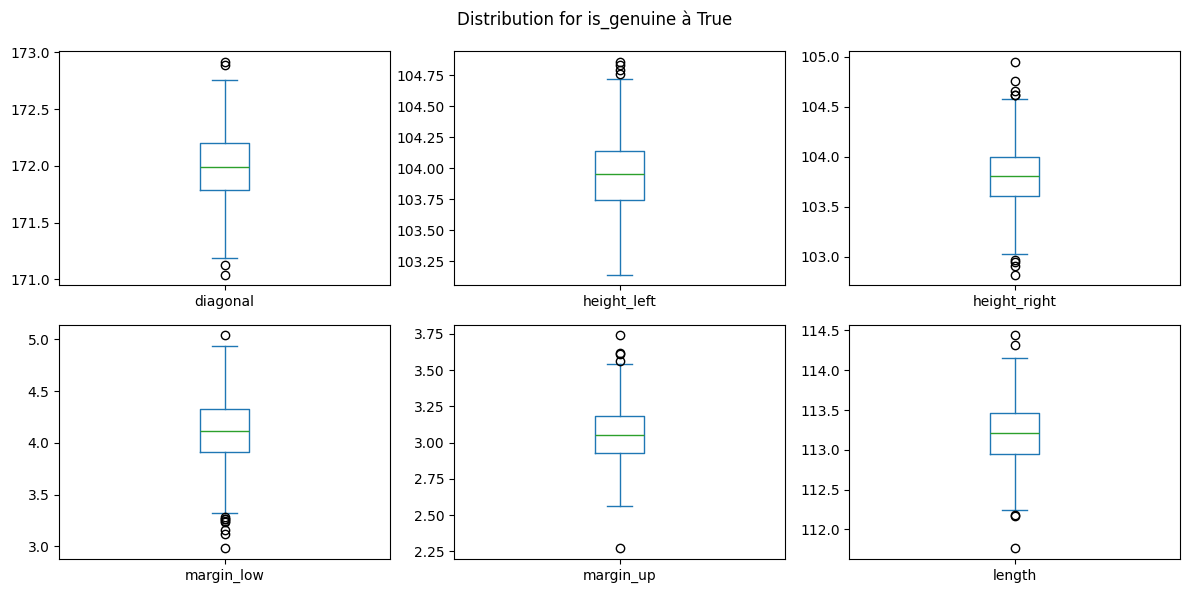

In [48]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))

fig.suptitle("Distribution for is_genuine à True")

ax=axes.flatten()
for i, col in enumerate(cols_billets):
  billets_df.loc[billets_df["is_genuine"]==True, col].plot(kind="box", ax=ax[i])
plt.tight_layout()
plt.show()

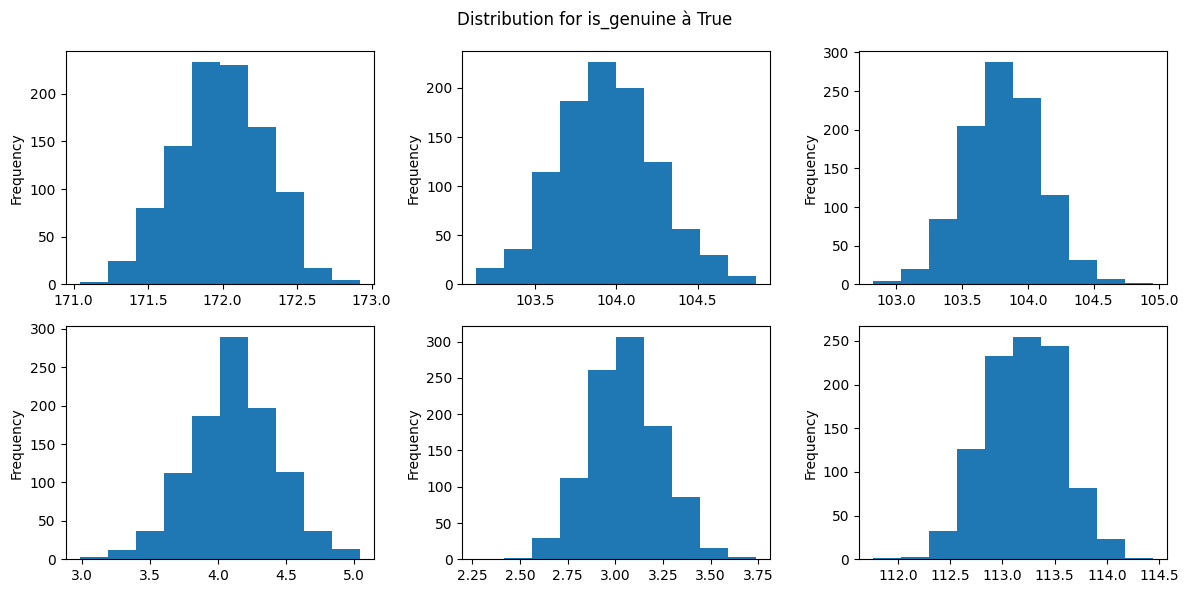

In [49]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))

fig.suptitle("Distribution for is_genuine à True")

ax=axes.flatten()
for i, col in enumerate(cols_billets):
  billets_df.loc[billets_df["is_genuine"]==True, col].plot(kind="hist", ax=ax[i])
plt.tight_layout()
plt.show()

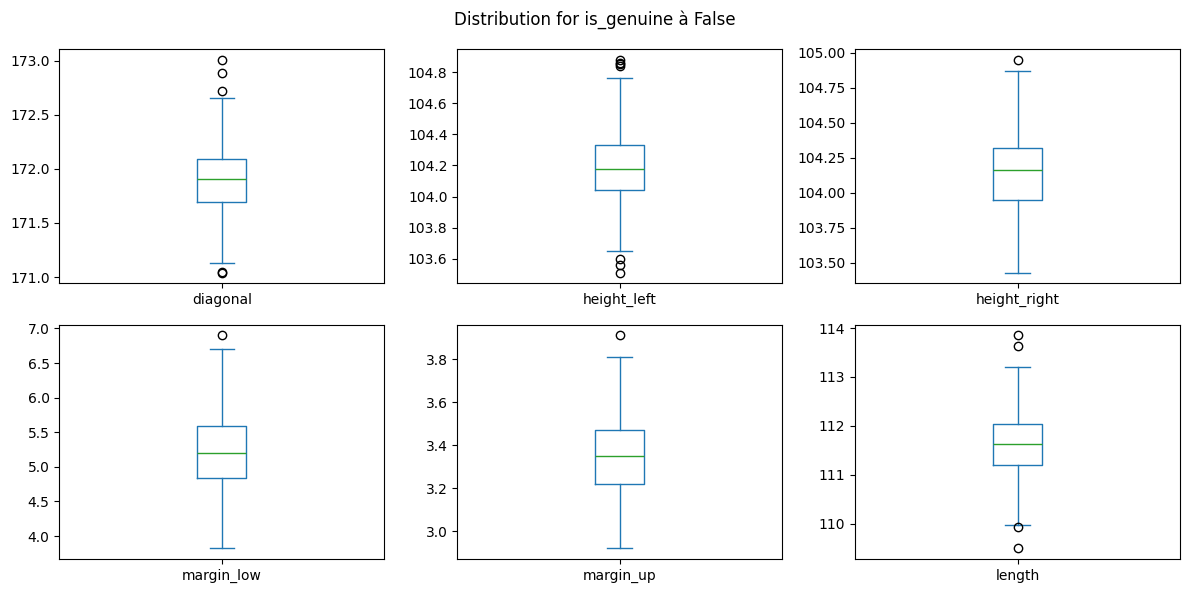

In [50]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))

fig.suptitle("Distribution for is_genuine à False")

ax=axes.flatten()

for i, col in enumerate(cols_billets):
  billets_df.loc[billets_df["is_genuine"]==False, col].plot(kind="box", ax=ax[i])
plt.tight_layout()
plt.show()

Some outliers may be observed, but all of its do not seem to be too far from the median line.

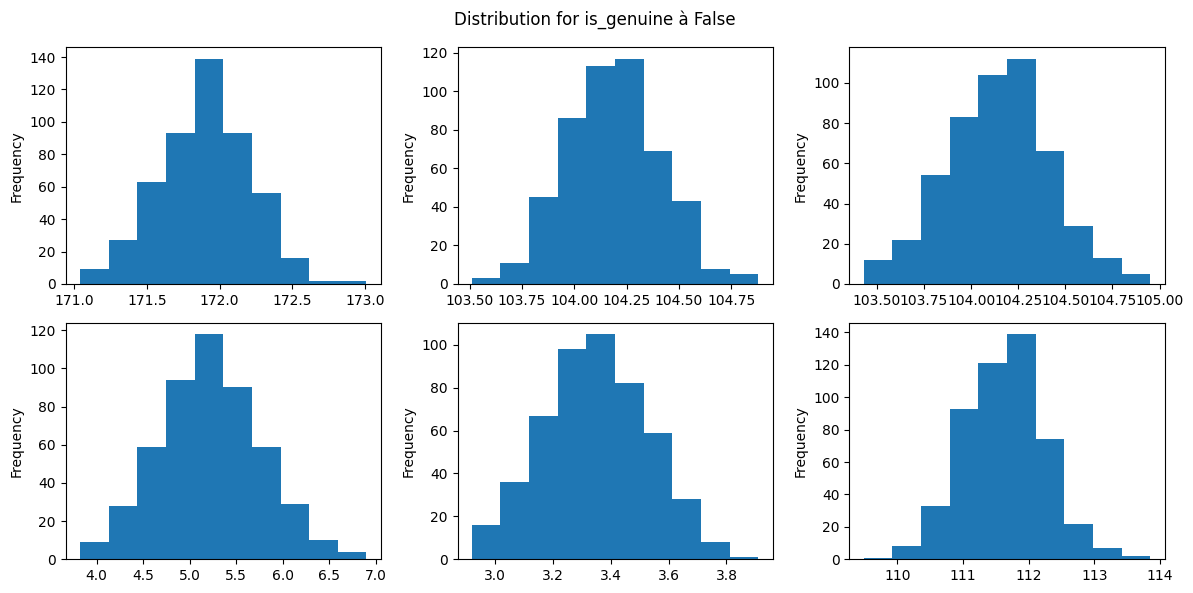

In [51]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))

fig.suptitle("Distribution for is_genuine à False")

ax=axes.flatten()
for i, col in enumerate(cols_billets):
  billets_df.loc[billets_df["is_genuine"]==False, col].plot(kind="hist", ax=ax[i])
plt.tight_layout()
plt.show()

So we see that if we take the number of false and true bills, each row is well balanced

Is Genuine feature distribution between False and True

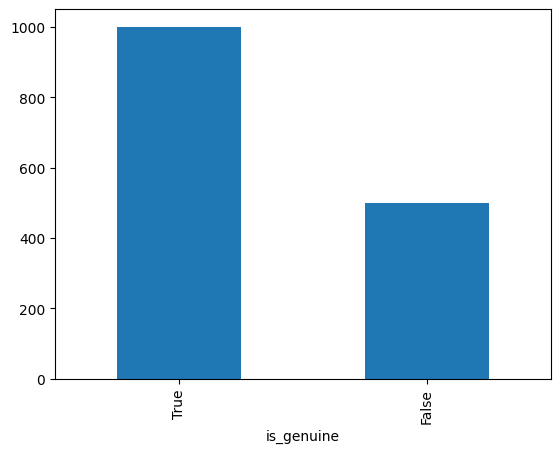

In [52]:
billets_df["is_genuine"].value_counts().plot(kind="bar")
plt.show()

In [53]:
true_genuine = billets_df[billets_df["is_genuine"]==True]["is_genuine"].count()
false_genuine = billets_df[billets_df["is_genuine"]==False]["is_genuine"].count()

ratio_true_genuine = true_genuine / (true_genuine + false_genuine)
print(f"Ratio true bills: {ratio_true_genuine*100:.2f}%")

Ratio true bills: 66.67%


As the classes are not balanced, then evaluating the best training should be based on a better metric than accuracy because it may have troubles to catch all the patterns.

In that case, f1 is a better metric because it gathers recall and precision and display a balance between those two

### **Main function**

Criterias:
- **Target :** "is_genuine" (Binary type) -> imply classification problem
- **Features:** Numerical, well-dsitributed, not heavily skewed -> few extreme outliers
- **Correlations;** a few feature are strongly correlated with the target -> complex interactions may exist between the others

Given those criterias, I chose to build a prediction model over 5 different models that can satsify those requirements

- **Logistic Regression**: Basic choice when hanlding binary classification problems. Assumes that it exists a kind of linear relationship pattern between the target and the features even if all of its are not all correlated.

- **K-Nearest Neighbors (KNN)**: which is a non-parametricn distance based classifier. Useful when linear models are enough accurate to capture a more complex pattern.

- **Random Forest Classifier**: Ensemble of decision trees that can handle non-linear relationsips between features. And robust to outliers.

- **Decision Tree Classifier**: non-linear model that split data based on feature threshold. As the two other previous one, accurate when data are not strongly correlated.

- **K-Means (Clustering)**: contrary to the four previous models, this one is unsupervised, implying the absence of any target. All data will be grouped depending on mutual characteristics. Always work better with scaled data to remove any mesure gaps between them.

All the other fuction can be used independently to specific processing steps when needed or included into a final wrapper function that accepts all relevant parameters, making the overall workflow easier and more convenient to use.

Other mischellaneous functions that can make some task easier to handle and avoid redundancy.

In [54]:
def detect_true_false_money(df, colum_target,
                            supervised_pipelines=None,
                            unsupervised_pipelines=None,
                            params_classification=None, params_clustering=None):
  # initiliaze the data
  X_low, y_low = state_data(df, colum_target)

  # split the data into trained model and test set
  X_train_low, X_test_low, y_train_low, y_test_low = train_split_data(X_low, y_low, size=0.2, stratify=y_low)

  if supervised_pipelines is not None:

    # Function for the supervised training and test part
    best_supervised_training_model = \
    evaluate_best_model_supervised_training(X_train_low,
                                X_test_low,
                                y_train_low,
                                y_test_low,
                                supervised_pipelines, params_classification)

    best_supervised_results_test = evaluate_best_supervised_model_confusion_matrix(
    X_train_low, X_test_low, y_train_low, y_test_low, best_supervised_training_model)

  if unsupervised_pipelines is not None:

    # Function for the supervised training and tests part
    best_unsupervised_training_model = \
    evaluate_best_unsupervised_model_training(X_train_low,
                                X_test_low,
                                unsupervised_pipelines, params_clustering)

    best_unsupervised_results_test = evaluate_best_unsupervised_model_confusion_matrix(
      X_train_low, X_test_low, best_unsupervised_training_model)

  return best_unsupervised_results_test, best_supervised_results_test

In [55]:
billets_df.to_csv(f"{root_project}data/billets_df_cleaned.csv", index=False)

In [56]:

  # Dataframe given
  # A model need to always be involved in a pipeline workflow in order to avoid data leakage
  # and always follow the same logic
  supervised_pipelines = {
    "logReg": make_pipeline(LogisticRegression, scale=True),
    "knn": make_pipeline(KNeighborsClassifier, scale=True),
    "rf": make_pipeline(RandomForestClassifier, scale=False),
    "dt" : make_pipeline(DecisionTreeClassifier, scale=False)
  }

  unsupervised_pipelines = {
    "kmeans": make_pipeline(KMeans, scale=True)
  }

  # instantiate the params for the model
  params_classification = {
    "logReg": {
        "model__C": [0.1, 1, 10],
        "model__solver": ["lbfgs"],
        "model__max_iter": [1000]
    },
    "knn": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"]
    },
    "rf": {
        "model__n_estimators": [100],
        "model__max_depth": [None, 10],
        "model__n_jobs": [-1],
        "model__random_state": [42]
    },
    "dt": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, None],
        "model__min_samples_split": [2, 10],
        "model__min_samples_leaf": [1, 5],
        "model__random_state": [42]
    }
  }

  params_clustering={
    "kmeans": {
            "model__n_clusters": billets_df['is_genuine'].nunique(),
            "model__random_state": 42
        }
  }

  best_unsupervised_results_test, best_supervised_results_test  = detect_true_false_money(
      billets_df, "is_genuine",
      supervised_pipelines,
      unsupervised_pipelines, params_classification, params_clustering)

  if best_unsupervised_results_test["best_test_score"] > best_supervised_results_test["best_test_score"]:
    best_results_test = best_unsupervised_results_test
  else:
    best_results_test = best_supervised_results_test

  print("----------------------------------------------")
  print("Test model")
  print("----------------------------------------------")
  print(f"Best model name on Test: {best_results_test['best_model_name']}")
  print(f"Trained score: {best_results_test['best_trained_score']:.4f} either {best_results_test['best_trained_score']*100:.2f}%")
  print(f"Trained params: {best_results_test['best_trained_params']}")
  print(f"Test score: {best_results_test['best_test_score']:.4f} either {best_results_test['best_test_score']*100:.2f}%")
  print(f"False positives: {best_results_test['FP']}")
  print(f"False negatives: {best_results_test['FN']}")
  print(f"Classification report: {best_results_test['classification_report']}")

----------------------------------------------
Test model
----------------------------------------------
Best model name on Test: KNeighborsClassifier
Trained score: 0.9944 either 99.44%
Trained params: {'model__n_neighbors': 5, 'model__weights': 'uniform'}
Test score: 0.9875 either 98.75%
False positives: 2
False negatives: 3
Classification report:               precision    recall  f1-score   support

       False       0.98      0.97      0.97       100
        True       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



In [58]:
import joblib

joblib.dump(best_results_test['best_model'], root_project + "models/model.pkl")

['/content/drive/MyDrive/projet_faux_monnayage/models/model.pkl']